
Title: Network Intrusion Detection using Machine Learning

Problem:
Organizations face cyber threats daily. The objective is to build a machine learning model that can predict whether a network session is malicious or safe based on activity patterns.


In [27]:
#Input variables (X): session_duration, bytes_sent, bytes_received, failed_logins, country_risk_score, is_vpn
#Output variable (y): is_malicious (0 = Safe, 1 = Attack)

## 1. Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [28]:
# 2. Load dataset

df = pd.read_csv("/content/network_security_dataset.csv")

In [29]:
df['is_malicious'] = (
    (df['failed_logins'] > 5) |
    (df['country_risk_score'] > 70) |
    (df['bytes_sent'] > 80000)
).astype(int)

**EDA** (Exploratory Data Analysis)

In [30]:
# 3. Basic checks on data

df

,session_duration,bytes_sent,bytes_received,failed_logins,country_risk_score,is_vpn,is_malicious
0,103,70363,76398,7,14,0,1
1,436,53217,59338,8,10,1,1
2,861,58494,2247,4,40,1,0
3,271,23882,99019,1,23,1,0
4,107,28554,99351,1,99,1,1
...,...,...,...,...,...,...,...
4995,295,17294,4776,7,68,1,1
4996,451,26911,86061,0,48,0,0
4997,904,72477,49784,9,66,0,1
4998,215,43823,13563,3,16,1,0


In [31]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 7 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   session_duration    5000 non-null   int64
 1   bytes_sent          5000 non-null   int64
 2   bytes_received      5000 non-null   int64
 3   failed_logins       5000 non-null   int64
 4   country_risk_score  5000 non-null   int64
 5   is_vpn              5000 non-null   int64
 6   is_malicious        5000 non-null   int64
dtypes: int64(7)
memory usage: 273.6 KB


In [32]:
df.describe()

,session_duration,bytes_sent,bytes_received,failed_logins,country_risk_score,is_vpn,is_malicious
count,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000
mean,506.696000,49907.130200,49797.118600,4.470000,50.022600,0.505400,0.660000
std,290.828313,29016.624418,29163.164579,2.862715,28.604345,0.500021,0.473756
min,1.000000,160.000000,102.000000,0.000000,1.000000,0.000000,0.000000
25%,254.000000,24790.000000,24070.000000,2.000000,25.000000,0.000000,0.000000
50%,511.000000,49346.500000,49819.500000,4.000000,50.000000,1.000000,1.000000
75%,762.000000,75621.750000,75095.250000,7.000000,74.250000,1.000000,1.000000
max,999.000000,99971.000000,99962.000000,9.000000,99.000000,1.000000,1.000000


In [33]:
df.shape

(5000, 7)

In [34]:
df.head()

,session_duration,bytes_sent,bytes_received,failed_logins,country_risk_score,is_vpn,is_malicious
0,103,70363,76398,7,14,0,1
1,436,53217,59338,8,10,1,1
2,861,58494,2247,4,40,1,0
3,271,23882,99019,1,23,1,0
4,107,28554,99351,1,99,1,1


In [35]:
df.tail()

,session_duration,bytes_sent,bytes_received,failed_logins,country_risk_score,is_vpn,is_malicious
4995,295,17294,4776,7,68,1,1
4996,451,26911,86061,0,48,0,0
4997,904,72477,49784,9,66,0,1
4998,215,43823,13563,3,16,1,0
4999,974,75335,25574,8,80,1,1


In [36]:
# 4. Delete columns with all unique values

# There is no unique value in this dataset

'''for col in df.columns:
    if df[col].nunique() == len(df):
        df.drop(columns=[col], inplace=True)'''

'for col in df.columns:\n    if df[col].nunique() == len(df):\n        df.drop(columns=[col], inplace=True)'

In [37]:
# 5. Handling NULL values

df.isnull().sum()

,0
session_duration,0
bytes_sent,0
bytes_received,0
failed_logins,0
country_risk_score,0
is_vpn,0
is_malicious,0


No null values found in this dataset

In [38]:
# 6. Handling duplicates

df.duplicated().sum()
df.drop_duplicates(inplace=True)

In [39]:
# 7. Split categorical and numerical data

#categorical_columns = df.select_dtypes(include="object").columns
#numerical_columns = df.select_dtypes(exclude="object").columns

There is no categorical data into this dataset

In [40]:
# 8. Handling error values

df.replace(["?", "unknown", "/"], np.nan, inplace=True)

In [41]:
# 9. Outlier handling (IQR method)

Q1 = df.quantile(0.25)
Q3 = df.quantile(0.75)
IQR = Q3 - Q1

df = df[~((df < (Q1 - 1.5 * IQR)) | (df > (Q3 + 1.5 * IQR))).any(axis=1)]

In [42]:
# Feature Engineering

df['total_bytes'] = df['bytes_sent'] + df['bytes_received']
df['login_ratio'] = df['failed_logins'] / (df['session_duration'] + 1)

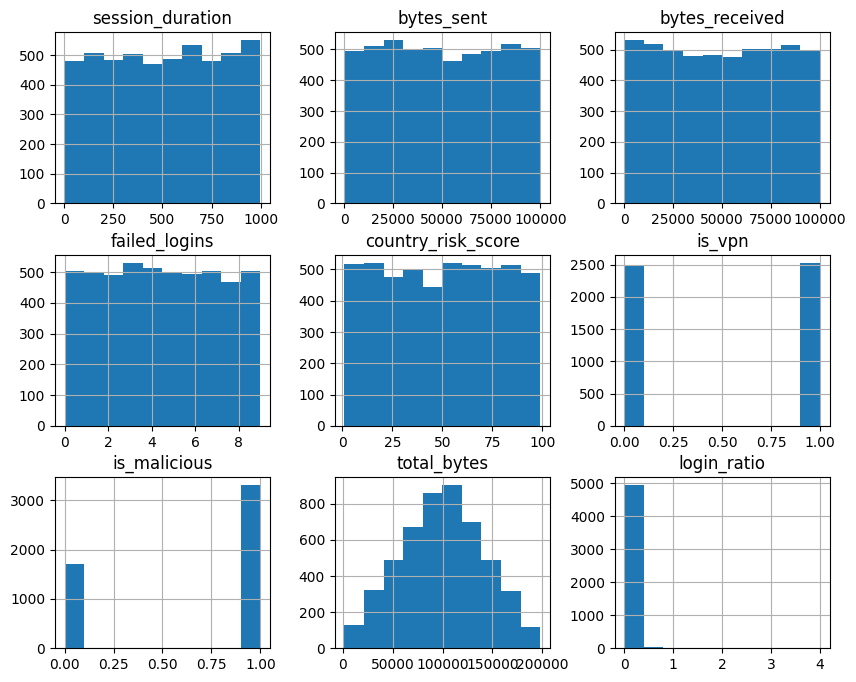

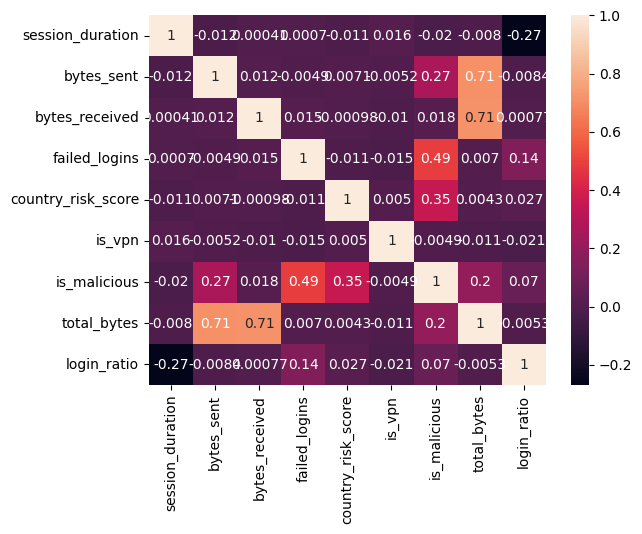

In [43]:
# 10. Univariate and bivariate analysis

# Univariate
df.hist(figsize=(10,8))
plt.show()

# Bivariate
sns.heatmap(df.corr(), annot=True)
plt.show()

In [44]:
# 11. Encoding

# Encoding is not required for this dataset

In [45]:
# 12. ML Model building

# a. Split X and y

X = df.drop("is_malicious", axis=1)
y = df["is_malicious"]

In [46]:
# b. Train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [47]:
# c. Initialize model

model = RandomForestClassifier()

In [48]:
# d. Model training

model.fit(X_train, y_train)

RandomForestClassifier()

In [49]:
# e. Prediction

y_pred = model.predict(X_test)

In [50]:
# Hyperparameter tuning

from sklearn.model_selection import GridSearchCV

params = {
    'n_estimators': [50, 100, 200],
    'max_depth': [5, 10, None]
}

grid = GridSearchCV(RandomForestClassifier(), params, cv=3)
grid.fit(X_train, y_train)

model = grid.best_estimator_

In [75]:
# f. Evaluation

# Accuracy
print("Accuracy:", accuracy_score(y_test, y_pred))

# Confusion Matrix
print(confusion_matrix(y_test, y_pred))

# Full Report
print(classification_report(y_test, y_pred))

Accuracy: 1.0
[[351   0]
 [  0 649]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       351
           1       1.00      1.00      1.00       649

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



Testing Model

In [55]:
new_data = pd.DataFrame({
    'session_duration': [300],
    'bytes_sent': [90000],
    'bytes_received': [40000],
    'failed_logins': [7],
    'country_risk_score': [80],
    'is_vpn': [1]
})

# 👉 Add engineered features (IMPORTANT)
new_data['total_bytes'] = new_data['bytes_sent'] + new_data['bytes_received']
new_data['login_ratio'] = new_data['failed_logins'] / (new_data['session_duration'] + 1)

# Predict
prediction = model.predict(new_data)

In [76]:
prediction = model.predict(new_data)

In [77]:
if prediction[0] == 1:
    print("⚠️ Malicious Activity Detected")
else:
    print("✅ Safe Session")

⚠️ Malicious Activity Detected


In [59]:
# To avoid addition of features manually every time

def preprocess_input(data):
    data['total_bytes'] = data['bytes_sent'] + data['bytes_received']
    data['login_ratio'] = data['failed_logins'] / (data['session_duration'] + 1)
    return data

new_data = preprocess_input(new_data)
prediction = model.predict(new_data)

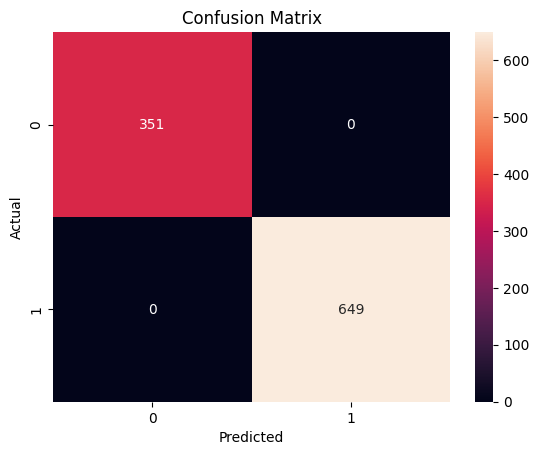

In [60]:
#Visualizing confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [62]:
#Feature importance

importance = model.feature_importances_
features = X.columns

feat_imp = pd.DataFrame({
    'Feature': features,
    'Importance': importance
}).sort_values(by='Importance', ascending=False)

print(feat_imp)

              Feature  Importance
3       failed_logins    0.360023
4  country_risk_score    0.292508
1          bytes_sent    0.177340
7         login_ratio    0.107704
6         total_bytes    0.040234
0    session_duration    0.012759
2      bytes_received    0.009284
5              is_vpn    0.000147


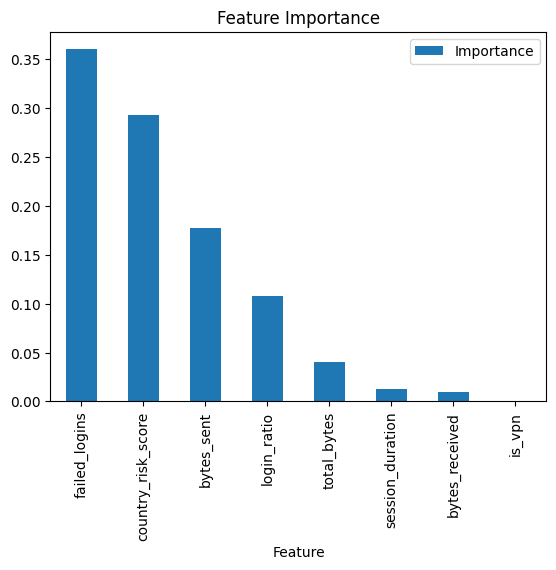

In [63]:
# Visualize

feat_imp.plot(kind='bar', x='Feature', y='Importance')
plt.title("Feature Importance")
plt.show()

Top features

*  failed_logins

*  country_risk_score





In [64]:
#Probability prediction

prob = model.predict_proba(new_data)
print(prob)

[[7.07406309e-04 9.99292594e-01]]


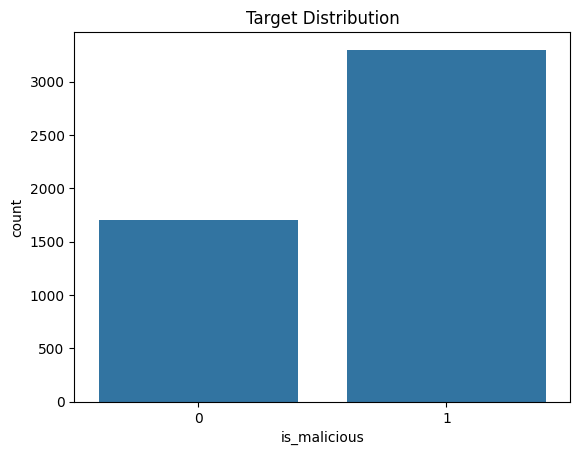

In [65]:
# Distribution visualization

sns.countplot(x='is_malicious', data=df)
plt.title("Target Distribution")
plt.show()

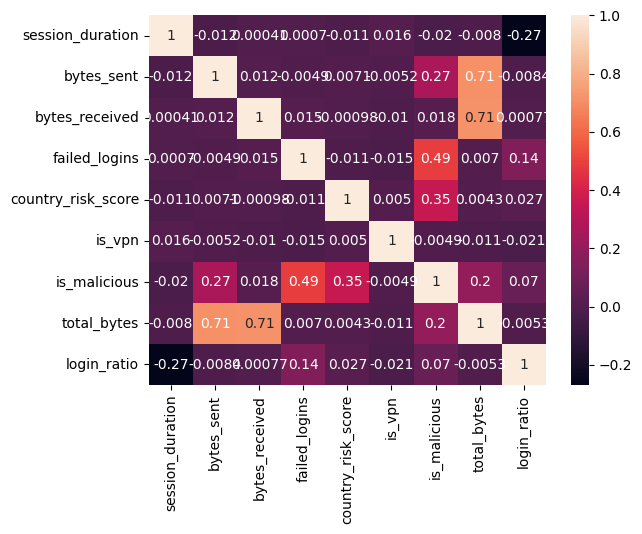

In [66]:
#Correlation Heatmap

sns.heatmap(df.corr(), annot=True)
plt.show()

Pipeline


In [67]:
# creating feature engineering function

def add_features(df):
    df = df.copy()
    df['total_bytes'] = df['bytes_sent'] + df['bytes_received']
    df['login_ratio'] = df['failed_logins'] / (df['session_duration'] + 1)
    return df

In [68]:
# Use function transformer

from sklearn.preprocessing import FunctionTransformer

feature_transformer = FunctionTransformer(add_features)

In [69]:
#Create pipeline
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier

pipeline = Pipeline([
    ('feature_engineering', feature_transformer),
    ('model', RandomForestClassifier())
])

In [80]:
#Train pipeline

pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_features at 0x7902fa7fcc20>)),
                ('scaling', StandardScaler()), ('pca', PCA(n_components=5)),
                ('model', RandomForestClassifier())])

In [71]:
#Predict

prediction = pipeline.predict(new_data)

In [72]:
# Add probability + Output

prob = pipeline.predict_proba(new_data)

if prediction[0] == 1:
    print("⚠️ Malicious Activity Detected")
else:
    print("✅ Safe Session")

print("Confidence:", round(max(prob[0]) * 100, 2), "%")

⚠️ Malicious Activity Detected
Confidence: 100.0 %


In [73]:
# PCA

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('feature_engineering', feature_transformer),
    ('scaling', StandardScaler()),
    ('pca', PCA(n_components=5)),
    ('model', RandomForestClassifier())
])

In [82]:
pipeline.fit(X_train, y_train)

Pipeline(steps=[('feature_engineering',
                 FunctionTransformer(func=<function add_features at 0x7902fa7fcc20>)),
                ('scaling', StandardScaler()), ('pca', PCA(n_components=5)),
                ('model', RandomForestClassifier())])

In [83]:
# Creating visual model using Streamlit

import joblib

joblib.dump(pipeline, "model.pkl")

['model.pkl']